<a href="https://colab.research.google.com/github/MayerT1/LiDAR_Dev/blob/main/Unified_Branch_Transformer_7_22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://chatgpt.com/c/687697b4-1aa0-8005-afa4-c4c7ecc40920

In [ ]:
!pip install rasterio geopandas pandas torch torchvision scikit-learn einops kornia


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 105.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 120.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 96.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 93.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 63.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2

In [ ]:
# print(torch.__version__)

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
import os

# Define the base project folder and subdirectories
base_dir = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project'
subdirs = [
    'target_data',
    'data',
    'data_NaN_filtered',
    'models',
    'scripts',
    'notebooks',
    'config',
    'results',
    'prediction_surface'
]

# Create each subdirectory
for subdir in subdirs:
    path = os.path.join(base_dir, subdir)
    os.makedirs(path, exist_ok=True)
    print(f"Created: {path}")


Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/target_data
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/data
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/data_NaN_filtered
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/models
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/scripts
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/notebooks
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/config
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/results
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/prediction_surface


# filter NaN in Geotiff

In [ ]:
import os
import numpy as np
import rasterio

base_dir = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project'
input_dir = os.path.join(base_dir, 'data')
output_dir = os.path.join(base_dir, 'data_NaN_filtered')

def fill_nans_with_mean(input_path, output_path):
    with rasterio.open(input_path) as src:
        profile = src.profile
        data = src.read(1).astype(np.float32)

        nan_mask = np.isnan(data)
        if np.any(nan_mask):
            mean_val = np.nanmean(data)
            data[nan_mask] = mean_val
            print(f"[INFO] Replaced NaNs in {os.path.basename(input_path)} with mean: {mean_val:.4f}")
        else:
            print(f"[INFO] No NaNs in {os.path.basename(input_path)}")

        # Write to new file
        with rasterio.open(output_path, 'w', **profile) as dst:
            dst.write(data, 1)

# Process all GeoTIFFs
for fname in os.listdir(input_dir):
    if fname.lower().endswith('.tif'):
        input_path = os.path.join(input_dir, fname)
        output_path = os.path.join(output_dir, fname)
        fill_nans_with_mean(input_path, output_path)


[INFO] Replaced NaNs in landsat_train_-8586_3519.tif with mean: 0.0418
[INFO] Replaced NaNs in landsat_train_-8586_3520.tif with mean: 0.0502
[INFO] Replaced NaNs in landsat_train_-8586_3521.tif with mean: 0.0445
[INFO] Replaced NaNs in landsat_train_-8586_3522.tif with mean: 0.0425
[INFO] Replaced NaNs in landsat_train_-8586_3523.tif with mean: 0.0691
[INFO] No NaNs in landsat_train_-8587_3514.tif
[INFO] Replaced NaNs in landsat_train_-8587_3512.tif with mean: 0.0620
[INFO] No NaNs in landsat_train_-8587_3516.tif
[INFO] No NaNs in landsat_train_-8587_3518.tif
[INFO] No NaNs in landsat_train_-8587_3521.tif
[INFO] No NaNs in landsat_train_-8587_3522.tif
[INFO] No NaNs in landsat_train_-8587_3523.tif
[INFO] No NaNs in landsat_train_-8587_3515.tif
[INFO] No NaNs in landsat_train_-8588_3512.tif
[INFO] No NaNs in landsat_train_-8588_3513.tif
[INFO] No NaNs in landsat_train_-8588_3514.tif
[INFO] No NaNs in landsat_train_-8588_3516.tif
[INFO] No NaNs in landsat_train_-8588_3517.tif
[INFO] No 

CPLE_AppDefinedError: tcap_train_-8588_3523.tif: TIFFReadDirectory:Failed to read directory at offset 430

# Map

In [ ]:
import os
import folium
import rasterio
from rasterio.warp import transform_bounds
from glob import glob
from shapely.geometry import box, Point, mapping
import geopandas as gpd
import pandas as pd

# ----------------- CONFIG -----------------
RASTER_DIR = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/data_NaN_filtered'
GEDI_CSV = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/target_data/filtered_csvs/GEDI_filtered_merged.csv'

COVARIATE_COLORS = {
    'dem': 'gray',
    'ls': 'green',
    'ndvi': 'purple',
    'savi': 'blue',
    'evi': 'orange',
    'slope': 'red',
    'aspect': 'brown',
    'elevation': 'black',
    'default': 'pink'
}

# ----------------- Load GEDI Targets -----------------
gedi_df = pd.read_csv(GEDI_CSV)

lat_col_candidates = ['latitude', 'lat', 'y']
lon_col_candidates = ['longitude', 'lon', 'x']

lat_col = next((col for col in lat_col_candidates if col in gedi_df.columns), None)
lon_col = next((col for col in lon_col_candidates if col in gedi_df.columns), None)

if not lat_col or not lon_col:
    raise ValueError(f"Latitude/Longitude columns not found. Expected one of {lat_col_candidates} and {lon_col_candidates}")

gedi_gdf = gpd.GeoDataFrame(
    gedi_df,
    geometry=gpd.points_from_xy(gedi_df[lon_col], gedi_df[lat_col]),
    crs='EPSG:4326'
)

# Create square buffer (~25m = ~0.000225 degrees at equator)
gedi_gdf['geometry'] = gedi_gdf.geometry.buffer(0.000225, cap_style=3)
gedi_gdf['block_id'] = gedi_gdf['geometry'].centroid.apply(lambda pt: f"{int(pt.x*1e4)}_{int(pt.y*1e4)}")

# ----------------- Load Raster Bounds -----------------
tif_files = glob(os.path.join(RASTER_DIR, '**/*.tif'), recursive=True)

raster_records = []
for tif in tif_files:
    try:
        with rasterio.open(tif) as src:
            bounds = transform_bounds(src.crs, 'EPSG:4326', *src.bounds)
            cov = next((c for c in COVARIATE_COLORS if c in tif.lower()), 'default')
            color = COVARIATE_COLORS[cov]
            geom = box(*bounds)
            block_id = os.path.basename(tif).split('_')[-1].replace('.tif', '')
            raster_records.append({
                'geometry': geom,
                'block_id': block_id,
                'covariate': cov,
                'resolution': src.res[0],
                'color': color,
                'filename': os.path.basename(tif)
            })
    except Exception as e:
        print(f"[WARN] Skipping {tif}: {e}")

raster_gdf = gpd.GeoDataFrame(raster_records, crs='EPSG:4326')

#----------------- Initialize Map -----------------
center = gedi_gdf.geometry.unary_union.centroid
m = folium.Map(location=[center.y, center.x], zoom_start=13, tiles="CartoDB positron")

# ----------------- Add GEDI Layer -----------------
for _, row in gedi_gdf.iterrows():
    coords = list(mapping(row.geometry)['coordinates'][0])
    folium.Polygon(
        locations=[(lat, lon) for lon, lat in coords],
        color='cyan',
        fill=True,
        fill_opacity=0.4,
        tooltip=f"<b>GEDI</b><br>Block: {row['block_id']}"
    ).add_to(m)

# ----------------- Add Raster Layers (Grouped by Covariate) -----------------
for covariate in raster_gdf['covariate'].unique():
    sub_gdf = raster_gdf[raster_gdf['covariate'] == covariate]
    for _, row in sub_gdf.iterrows():
        coords = list(mapping(row.geometry)['coordinates'][0])
        folium.Polygon(
            locations=[(lat, lon) for lon, lat in coords],
            color=row['color'],
            weight=1,
            fill=True,
            fill_opacity=0.2,
            tooltip=f"""
                <b>{covariate.upper()}</b><br>
                Block ID: {row['block_id']}<br>
                Resolution: {row['resolution']}<br>
                File: {row['filename']}
            """
        ).add_to(m)

# ----------------- Show Map -----------------
m


In [ ]:
raster_gdf

Average GEDI values per 32x32 block

In [ ]:
# ----------------- Ensure Same CRS -----------------
gedi_gdf = gedi_gdf.to_crs('EPSG:4326')
raster_gdf = raster_gdf.to_crs('EPSG:4326')

# ----------------- Spatial Join -----------------
# Each GEDI point gets linked to overlapping raster tile
joined = gpd.sjoin(gedi_gdf, raster_gdf, how='inner', predicate='intersects')

# ----------------- Compute Per-Tile Averages -----------------
target_cols = ['pai', 'fhd_normal', 'rh100']

# Check original target columns exist
for col in target_cols:
    if col not in joined.columns:
        raise ValueError(f"Missing required column '{col}' in joined GeoDataFrame")

# Group by raster polygon index and compute averages
avg_df = (
    joined
    .groupby('index_right')[target_cols]
    .mean()
    .rename(columns={
        'pai': 'avg_pai',
        'fhd_normal': 'avg_fhd_normal',
        'rh100': 'avg_rh100'
    })
    .reset_index()
)

# ----------------- Merge Averages with Raster Polygons -----------------
# Reset index to get 'index_right' for joining
raster_meta = raster_gdf.reset_index().rename(columns={'index': 'index_right'})

# Merge averages onto raster polygons
raster_with_avg = raster_meta.merge(avg_df, on='index_right', how='left')

# ----------------- Finalize Output -----------------
# raster_with_avg is a GeoDataFrame with one polygon per raster tile,
# and averaged GEDI target values per polygon.

# Select relevant columns (add more if needed)
final_cols = [
    'geometry', 'block_id', 'covariate', 'filename', 'resolution',
    'avg_pai', 'avg_fhd_normal', 'avg_rh100'
]

final_df = raster_with_avg[final_cols].copy()

# ----------------- Output -----------------
print("✅ Final raster polygons with averaged GEDI target values:")
print(final_df.head())
print(f"\n✅ Total raster polygons with GEDI data: {len(final_df)}")


In [ ]:
for col in final_df.columns:
    print(col)


In [ ]:
# final_df

avg_target_df = final_df.dropna()

avg_target_df


In [ ]:
# # Make sure the directory exists and save the DataFrame
# save_path = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/target_data/filtered_csvs/avg_target_df.csv'
# avg_target_df.to_csv(save_path, index=False)


# EO and Band lists for context

In [ ]:
eo_list = ['s1', 's2', 'landsat', 'landsat_idx', 'hls', 'tcap', 'dem', 's2_idx']

spatial_res = {
    's1': 10, 's2': 20, 's2_idx': 20,
    'landsat': 30, 'landsat_idx': 30, 'hls': 30,
    'tcap': 30, 'dem': 30
}

bands_per_cov = {
    's1': 4, 's2': 6, 's2_idx': 8,
    'landsat': 6, 'landsat_idx': 7, 'hls': 7,
    'tcap': 6, 'dem': 2
}


In [ ]:
data_dir = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/data_NaN_filtered'

# Train, Test, Val Augmentaion: goal of improving semantic richness at the embedding level



In [ ]:
import random
import numpy as np
import torchvision.transforms.functional as TF
from scipy.ndimage import shift, rotate

def random_flip(img):
    # img shape: (C, H, W)
    if random.random() > 0.5:
        img = np.flip(img, axis=2)  # horizontal flip
    if random.random() > 0.5:
        img = np.flip(img, axis=1)  # vertical flip
    return img.copy()

def random_rotate(img, max_angle=30):
    # Rotate by random angle between -max_angle and max_angle
    angle = random.uniform(-max_angle, max_angle)
    # rotate expects (H,W,C), so transpose then rotate and transpose back
    img_t = np.transpose(img, (1, 2, 0))
    img_r = rotate(img_t, angle=angle, axes=(0,1), reshape=False, order=1, mode='reflect')
    return np.transpose(img_r, (2, 0, 1))

def random_shift(img, max_shift=3):
    # Shift image randomly by -max_shift to max_shift pixels in x and y
    shift_x = random.uniform(-max_shift, max_shift)
    shift_y = random.uniform(-max_shift, max_shift)
    img_t = np.transpose(img, (1, 2, 0))
    img_s = shift(img_t, shift=(shift_y, shift_x, 0), order=1, mode='reflect')
    return np.transpose(img_s, (2, 0, 1))

def random_augment(img):
    # Apply random augmentations in sequence
    img_aug = img.copy()
    img_aug = random_flip(img_aug)
    img_aug = random_rotate(img_aug)
    img_aug = random_shift(img_aug)
    return img_aug


view of the effect of data augmentation

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_augmentation_effect(avg_target_df, eo_list, augmentation_multiplier=5):
    # Count original sample counts per EO and split
    counts = []
    for eo in eo_list:
        for split in ['train', 'val', 'test']:
            mask = avg_target_df['filename'].str.contains(f'{eo}_{split}_')
            count = mask.sum()
            counts.append({'eo': eo, 'split': split, 'original_count': count})

    df_counts = pd.DataFrame(counts)

    # Calculate effective counts after augmentation (only train augmented)
    def effective_count(row):
        if row['split'] == 'train':
            return row['original_count'] * (1 + augmentation_multiplier)
        else:
            return row['original_count']

    df_counts['augmented_count'] = df_counts.apply(effective_count, axis=1)

    print("\nSample counts before and after augmentation (assuming augmentation multiplier={}):".format(augmentation_multiplier))
    print(df_counts)

    # Plotting
    fig, ax = plt.subplots(figsize=(14, 6))
    width = 0.35  # bar width

    x = np.arange(len(df_counts['eo'].unique()) * 3)  # eo * splits in order

    # Group by eo then split order ['train','val','test']
    labels = []
    original_vals = []
    augmented_vals = []

    for eo in eo_list:
        for split in ['train', 'val', 'test']:
            subset = df_counts[(df_counts['eo'] == eo) & (df_counts['split'] == split)]
            labels.append(f"{eo}_{split}")
            if not subset.empty:
                original_vals.append(subset['original_count'].values[0])
                augmented_vals.append(subset['augmented_count'].values[0])
            else:
                original_vals.append(0)
                augmented_vals.append(0)

    ax.bar(x - width/2, original_vals, width, label='Original count')
    ax.bar(x + width/2, augmented_vals, width, label='After augmentation')

    ax.set_ylabel('Number of samples')
    ax.set_title('Dataset Size Before and After Augmentation per EO & Split')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.legend()
    plt.tight_layout()
    plt.show()

    return df_counts

# Usage example, put this before Step 2 in your pipeline script:
augmentation_multiplier = 5  # how many augmentations you want to simulate per training patch
df_stats = plot_augmentation_effect(avg_target_df, eo_list, augmentation_multiplier=augmentation_multiplier)


# Unifed code for all Vit Branch dev

# EO Vit Branch train, tune, embed

* Loads EO data per product (like 'landsat', 's1', etc.)

* Augments only the train data to expand it

* Splits data into Train/Test/Val splits (augment train, val for evaluation only)

* Normalizes per band inside the model (learned normalization or per batch)

* Has a ViT model running on 32x32 patches for that EO product

* Has hyperparameters (batch norm, epochs, lr, etc.) tunable with a grid search or similar

* Trains on Train, validates on Test, finally evaluates on Val

* Logs verbose progress, including losses and metrics, plots training loss curves

* After training each EO ViT, extracts embeddings with spatial info on val dataset



In [ ]:
#dev

import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import rasterio
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.manifold import TSNE
import torchvision.transforms as T
import torchvision.transforms.functional as TF
import kornia.augmentation as K
import torch.nn as nn

import pandas as pd
from itertools import product

# --- EO config ---
eo_list = ['s1', 's2', 'landsat', 'landsat_idx', 'hls', 'tcap', 'dem', 's2_idx']
bands_per_cov = {
    's1': 4, 's2': 6, 's2_idx': 8,
    'landsat': 6, 'landsat_idx': 7, 'hls': 7,
    'tcap': 6, 'dem': 2
}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# # --- Augmentation Transform (on-the-fly for train only) ---

class RobustAugmentation(nn.Module):
    def __init__(self):
        super().__init__()
        self.transforms = nn.Sequential(
            K.RandomHorizontalFlip(p=0.5),
            K.RandomVerticalFlip(p=0.5),
            K.RandomAffine(degrees=20, translate=(0.1, 0.1), p=0.7)
        )

    def forward(self, x):
        return self.transforms(x)


# === Element 3: Add Activation Layer ===
# print("element 3")

# class ActivatedEOViT(nn.Module):
#     def __init__(self, base_model):
#         super().__init__()
#         self.base_model = base_model
#         self.activation = nn.ReLU()

#     def forward(self, x):
#         x = self.base_model.input_scaler(x)
#         # print("Element 2: Debug print: input_scaler.weight shape:", self.base_model.input_scaler.weight.shape)  # Element 2: Debug print
#         x = self.base_model.input_norm(x)
#         x = self.base_model.patch_embed(x).flatten(2).transpose(1, 2)

#         cls_tokens = self.base_model.cls_token.expand(x.size(0), -1, -1)
#         x = torch.cat((cls_tokens, x), dim=1)
#         x = x + self.base_model.pos_embed

#         x = self.base_model.transformer(x)
#         x = self.activation(x[:, 0])
#         return self.base_model.mlp_head(x).squeeze(1)

#     def extract_cls_embeddings(self, x):
#         return self.base_model.extract_cls_embeddings(x)


class ActivatedEOViT(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.base_model = base_model
        self.activation = nn.ReLU()

    def forward(self, x, spatial_coords=None):
        cls_output = self.base_model(x, spatial_coords=spatial_coords)  # includes Option B
        cls_output = self.activation(cls_output)

        # === OPTION D: Concatenate spatial coords before MLP ===
        if spatial_coords is not None:
            x_combined = torch.cat([cls_output, spatial_coords], dim=1)
        else:
            x_combined = cls_output

        return self.base_model.mlp_head(x_combined).squeeze(1)

    def extract_cls_embeddings(self, x, spatial_coords=None):
        return self.base_model.extract_cls_embeddings(x, spatial_coords=spatial_coords)


# --- Dataset ---
class EODataset(Dataset):
    def __init__(self, eo_name, data_dir, split, target_df, patch_size=32, transform=None):
        self.eo_name = eo_name
        self.data_dir = data_dir
        self.split = split
        self.patch_size = patch_size
        self.target_df = target_df
        self.transform = transform

        all_files = sorted([f for f in os.listdir(data_dir)
                            if f.startswith(f"{eo_name}_{split}_") and f.endswith(".tif")])
        target_files = set(target_df['filename'])
        self.files = [f for f in all_files if f in target_files]

        print(f"[INFO] {split.upper()} dataset for {eo_name} initialized with {len(self.files)} tiles.")

    def __len__(self):
        return len(self.files)


    def __getitem__(self, idx):
        filename = self.files[idx]
        filepath = os.path.join(self.data_dir, filename)

        with rasterio.open(filepath) as src:
            array_resized = src.read(
                out_shape=(src.count, self.patch_size, self.patch_size),
                resampling=rasterio.enums.Resampling.bilinear
            )
            bounds = src.bounds
            x_center = (bounds.left + bounds.right) / 2
            y_center = (bounds.top + bounds.bottom) / 2

        img_tensor = torch.from_numpy(array_resized).float()  # [C, H, W]

        if self.transform is not None and self.split == 'train':
            img_tensor = self.transform(img_tensor.unsqueeze(0))  # [1, C, H, W]
            img_tensor = img_tensor.squeeze(0)  # back to [C, H, W]

        row = self.target_df[self.target_df['filename'] == filename]
        target = row['avg_pai'].values[0] if len(row) > 0 else 0.0
        target_tensor = torch.tensor(target, dtype=torch.float32)
        spatial_tensor = torch.tensor([x_center, y_center], dtype=torch.float32)

        return img_tensor, target_tensor, spatial_tensor

# --- Vision Transformer Model ---
# class EOViT(nn.Module):
#     def __init__(self, in_channels, patch_size=16, emb_dim=64, num_heads=4, num_layers=2, patch_dim=32, batch_norm=True):
#         super().__init__()
#         self.batch_norm = batch_norm
#         self.input_scaler = nn.Conv2d(in_channels, in_channels, kernel_size=1, stride=1, padding=0, bias=True)
#         self.input_norm = nn.BatchNorm2d(in_channels) if batch_norm else nn.Identity()
#         self.patch_embed = nn.Conv2d(in_channels, emb_dim, kernel_size=patch_size, stride=patch_size)

#         num_patches = (patch_dim // patch_size) ** 2
#         self.cls_token = nn.Parameter(torch.randn(1, 1, emb_dim))
#         self.pos_embed = nn.Parameter(torch.randn(1, num_patches + 1, emb_dim))

#         encoder_layer = nn.TransformerEncoderLayer(d_model=emb_dim, nhead=num_heads, batch_first=True)
#         self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

#         self.mlp_head = nn.Sequential(nn.LayerNorm(emb_dim), nn.Linear(emb_dim, 1))

#         print(f"[INFO] Initialized EOViT with batch_norm={batch_norm} for {in_channels} input channels.")

#     def forward(self, x):
#         x = self.input_scaler(x)
#         x = self.input_norm(x)
#         x = self.patch_embed(x).flatten(2).transpose(1, 2)

#         cls_tokens = self.cls_token.expand(x.size(0), -1, -1)
#         x = torch.cat((cls_tokens, x), dim=1)
#         x = x + self.pos_embed

#         x = self.transformer(x)
#         return self.mlp_head(x[:, 0]).squeeze(1)

#     def extract_cls_embeddings(self, x):
#         x = self.input_scaler(x)
#         x = self.input_norm(x)
#         x = self.patch_embed(x).flatten(2).transpose(1, 2)
#         cls_tokens = self.cls_token.expand(x.size(0), -1, -1)
#         x = torch.cat((cls_tokens, x), dim=1)
#         x = x + self.pos_embed
#         x = self.transformer(x)
#         return x[:, 0]

class EOViT(nn.Module):
    def __init__(self, in_channels, patch_size=16, emb_dim=64, num_heads=4, num_layers=2, patch_dim=32, batch_norm=True):
        super().__init__()
        self.batch_norm = batch_norm
        self.input_scaler = nn.Conv2d(in_channels, in_channels, kernel_size=1, stride=1, padding=0, bias=True)
        self.input_norm = nn.BatchNorm2d(in_channels) if batch_norm else nn.Identity()
        self.patch_embed = nn.Conv2d(in_channels, emb_dim, kernel_size=patch_size, stride=patch_size)

        num_patches = (patch_dim // patch_size) ** 2
        self.cls_token = nn.Parameter(torch.randn(1, 1, emb_dim))
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches + 1, emb_dim))

        # === OPTION B: Learnable spatial coordinate embedding ===
        self.spatial_coord_embedding = nn.Linear(2, emb_dim)

        encoder_layer = nn.TransformerEncoderLayer(d_model=emb_dim, nhead=num_heads, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # === OPTION D will be handled in ActivatedEOViT ===
        self.mlp_head = nn.Sequential(nn.LayerNorm(emb_dim + 2), nn.Linear(emb_dim + 2, 1))

        print(f"[INFO] Initialized EOViT with spatial embedding for {in_channels} input channels.")

    def forward(self, x, spatial_coords=None):
        x = self.input_scaler(x)
        x = self.input_norm(x)
        x = self.patch_embed(x).flatten(2).transpose(1, 2)

        cls_tokens = self.cls_token.expand(x.size(0), -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.pos_embed

        # === OPTION B: Add spatial coord embedding to cls_token ===
        if spatial_coords is not None:
            spatial_emb = self.spatial_coord_embedding(spatial_coords).unsqueeze(1)  # [B, 1, D]
            x[:, 0:1, :] += spatial_emb  # modify CLS token

        x = self.transformer(x)
        return x[:, 0]  # return only CLS token

    def extract_cls_embeddings(self, x, spatial_coords=None):
        x = self.forward(x, spatial_coords)
        return x




# --- Training / Evaluation Loop ---
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    for batch_idx, (x, y, _) in enumerate(dataloader):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if batch_idx % 10 == 0:
            print(f"[TRAIN] Batch {batch_idx} Loss: {loss.item():.4f}")

    avg_loss = running_loss / len(dataloader)
    print(f"[TRAIN] Epoch Avg Loss: {avg_loss:.4f}")
    return avg_loss


def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    preds, trues = [], []
    with torch.no_grad():
        for x, y, _ in dataloader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            loss = criterion(outputs, y)
            running_loss += loss.item()
            preds.append(outputs.cpu().numpy())
            trues.append(y.cpu().numpy())
    avg_loss = running_loss / len(dataloader)
    preds = np.concatenate(preds)
    trues = np.concatenate(trues)
    rmse = np.sqrt(mean_squared_error(trues, preds))
    print(f"[EVAL] Avg Loss: {avg_loss:.4f} RMSE: {rmse:.4f}")
    return avg_loss, rmse


# # --- Hyperparameter grid search ---

def hyperparameter_search(eo, train_dataset, test_dataset, batch_size=8, epochs=10, device='cpu'):
    print(f"[INFO] Starting hyperparameter search for {eo}")
    best_rmse = float('inf')
    best_params = None
    best_model = None

    batch_norm_options = [True] # [True, False]
    lr_options = [1e-4] #[1e-3, 5e-4, 1e-4]
    epoch_options = [50] # [20,30]
    optimizers = ['Adam'] # ['Adam', 'AdamW']

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size)

    for batch_norm in batch_norm_options:
        for lr in lr_options:
            for opt_name in optimizers:
                for n_epochs in epoch_options:
                    print(f"\n[GRID SEARCH] batch_norm={batch_norm}, lr={lr}, opt={opt_name}, epochs={n_epochs}")
                    base_model = EOViT(
                        in_channels=bands_per_cov[eo],
                        patch_size=16,
                        emb_dim=64,
                        num_heads=4,
                        num_layers=2,
                        patch_dim=train_dataset.patch_size,
                        batch_norm=batch_norm
                    ).to(device)

                    model = ActivatedEOViT(base_model).to(device)

                    optimizer = torch.optim.Adam(model.parameters(), lr=lr) if opt_name == 'Adam' \
                        else torch.optim.AdamW(model.parameters(), lr=lr)
                    criterion = nn.MSELoss()

                    train_losses, test_losses = [], []
                    for epoch in range(n_epochs):
                        print(f"[EPOCH {epoch+1}/{n_epochs}]")
                        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
                        test_loss, test_rmse = evaluate(model, test_loader, criterion, device)
                        train_losses.append(train_loss)
                        test_losses.append(test_loss)

                    plt.figure()
                    plt.plot(range(1, n_epochs+1), train_losses, label='Train Loss')
                    plt.plot(range(1, n_epochs+1), test_losses, label='Test Loss')
                    plt.title(f'{eo} Loss\nBN={batch_norm}, LR={lr}, OPT={opt_name}')
                    plt.xlabel('Epoch')
                    plt.ylabel('Loss')
                    plt.legend()
                    plt.show()

                    if test_rmse < best_rmse:
                        best_rmse = test_rmse
                        best_params = {
                            'batch_norm': batch_norm,
                            'lr': lr,
                            'epochs': n_epochs,
                            'optimizer': opt_name
                        }
                        best_model = model

    print(f"[INFO] Best params for {eo}: {best_params} with RMSE={best_rmse:.4f}")
    return best_model, best_params


# --- Extract embeddings and spatial info for val set ---
def extract_embeddings_and_spatial(model, dataloader, device):
    model.eval()
    all_embeddings, all_targets, all_coords = [], [], []

    with torch.no_grad():
        for x, y, coord in dataloader:
            x = x.to(device)
            emb = model.extract_cls_embeddings(x).cpu()
            all_embeddings.append(emb)
            all_targets.append(y)
            all_coords.append(coord)

    embeddings = torch.cat(all_embeddings, dim=0).numpy()
    targets = torch.cat(all_targets, dim=0).numpy()
    coords = torch.cat(all_coords, dim=0).numpy()

    print(f"[INFO] Extracted {len(embeddings)} embeddings with spatial info for validation.")
    return embeddings, targets, coords


# --- Main pipeline ---
def main_pipeline(data_root_dir, avg_target_df, patch_size=32, batch_size=8):
    embedding_dict = {}
    augmentation_transform = RobustAugmentation() #RandomFlipRotateShift(max_shift=3)

    for eo in eo_list:
        print(f"\n===== Processing EO product: {eo} =====")

        # --- Initialize tracking list ---
        model_logs = []

        # Define tuning space to count total runs (match hyperparameter_search)
        batch_norm_options = [True] # [True, False]
        lr_options = [1e-4] #[1e-3, 5e-4, 1e-4]
        epoch_options = [50] # [20,30]
        optimizer_options = ['Adam'] # ['Adam', 'AdamW']



        total_runs_per_eo = len(batch_norm_options) * len(lr_options) * len(epoch_options) * len(optimizer_options)
        total_models = total_runs_per_eo * len(eo_list)
        print(f"\n[INFO] ****About to train {total_models} models ({total_runs_per_eo} per EO product × {len(eo_list)} EO products)***!")


        # Prepare dataframes filtered by EO and split
        eo_train_df = avg_target_df[avg_target_df['filename'].str.contains(f'{eo}_train_')]
        eo_val_df = avg_target_df[avg_target_df['filename'].str.contains(f'{eo}_val_')]
        eo_test_df = avg_target_df[avg_target_df['filename'].str.contains(f'{eo}_test_')]

        # Construct datasets
        train_dataset = EODataset(eo, data_root_dir, 'train', eo_train_df, patch_size=patch_size, transform=augmentation_transform)
        test_dataset = EODataset(eo, data_root_dir, 'test', eo_test_df, patch_size=patch_size, transform=None)
        val_dataset = EODataset(eo, data_root_dir, 'val', eo_val_df, patch_size=patch_size, transform=None)

        # Hyperparameter tuning & train best model on train/test splits
        default_epochs = 10
        best_model, best_params = hyperparameter_search(eo, train_dataset, test_dataset, batch_size=batch_size, epochs=default_epochs, device=device)

        # best_model, best_params = hyperparameter_search(eo, train_dataset, test_dataset, batch_size=batch_size, epochs=best_params.get('epochs', 10), device=device)

        # Final evaluation on validation dataset with best model
        val_loader = DataLoader(val_dataset, batch_size=batch_size)
        criterion = nn.MSELoss()
        val_loss, val_rmse = evaluate(best_model, val_loader, criterion, device)
        print(f"[FINAL EVAL] Validation Loss: {val_loss:.4f}, RMSE: {val_rmse:.4f}")

        # Extract embeddings + spatial info on val set
        embedding, targets, coords = extract_embeddings_and_spatial(best_model, val_loader, device)
        embedding_dict[eo] = {
            'model': best_model,
            'params': best_params,
            'val_loss': val_loss,
            'val_rmse': val_rmse,
            'embeddings': embedding,
            'targets': targets,
            'coords': coords
        }

        # Log the run
        model_logs.append({
        'eo_product': eo,
        'batch_norm': best_params['batch_norm'],
        'lr': best_params['lr'],
        'epochs': best_params['epochs'],
        'optimizer': best_params.get('optimizer', 'adam'),  # default fallback
        'val_rmse': val_rmse,
        'val_loss': val_loss
        })

    print("[INFO] Completed training and embedding extraction for all EO products.")
    return embedding_dict


# === USAGE EXAMPLE ===
# Make sure avg_target_df is a DataFrame with columns ['filename', 'avg_pai']
data_root_dir = data_dir
embedding_dict = main_pipeline(data_root_dir, avg_target_df)



In [ ]:
### this block works saving it as is to test the features above

# import os
# import random
# import numpy as np
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# from torch.utils.data import Dataset, DataLoader, random_split
# import rasterio
# import matplotlib.pyplot as plt
# from sklearn.metrics import mean_squared_error
# from sklearn.manifold import TSNE

# # --- EO config ---
# eo_list = ['s1', 's2', 'landsat', 'landsat_idx', 'hls', 'tcap', 'dem', 's2_idx']
# bands_per_cov = {
#     's1': 4, 's2': 6, 's2_idx': 8,
#     'landsat': 6, 'landsat_idx': 7, 'hls': 7,
#     'tcap': 6, 'dem': 2
# }

# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# # --- Augmentation Transform (on-the-fly for train only) ---
# class RandomFlipRotateShift:
#     def __init__(self, max_shift=3):
#         self.max_shift = max_shift

#     def __call__(self, img_tensor):
#         # img_tensor shape: (C, H, W)
#         if random.random() > 0.5:
#             img_tensor = torch.flip(img_tensor, dims=[2])
#         if random.random() > 0.5:
#             img_tensor = torch.flip(img_tensor, dims=[1])
#         k = random.randint(0, 3)
#         img_tensor = torch.rot90(img_tensor, k, dims=[1, 2])

#         shift_x = random.randint(-self.max_shift, self.max_shift)
#         shift_y = random.randint(-self.max_shift, self.max_shift)
#         img_tensor = F.pad(img_tensor, (self.max_shift, self.max_shift, self.max_shift, self.max_shift), mode='reflect')
#         h, w = img_tensor.shape[1], img_tensor.shape[2]
#         start_x = self.max_shift + shift_x
#         start_y = self.max_shift + shift_y
#         img_tensor = img_tensor[:, start_y:start_y+(h - 2*self.max_shift), start_x:start_x+(w - 2*self.max_shift)]

#         return img_tensor


# # --- Dataset ---
# class EODataset(Dataset):
#     def __init__(self, eo_name, data_dir, split, target_df, patch_size=32, transform=None):
#         self.eo_name = eo_name
#         self.data_dir = data_dir
#         self.split = split
#         self.patch_size = patch_size
#         self.target_df = target_df
#         self.transform = transform

#         all_files = sorted([f for f in os.listdir(data_dir)
#                             if f.startswith(f"{eo_name}_{split}_") and f.endswith(".tif")])
#         target_files = set(target_df['filename'])
#         self.files = [f for f in all_files if f in target_files]

#         print(f"[INFO] {split.upper()} dataset for {eo_name} initialized with {len(self.files)} tiles.")

#     def __len__(self):
#         return len(self.files)

#     def __getitem__(self, idx):
#         filename = self.files[idx]
#         filepath = os.path.join(self.data_dir, filename)

#         with rasterio.open(filepath) as src:
#             array_resized = src.read(
#                 out_shape=(src.count, self.patch_size, self.patch_size),
#                 resampling=rasterio.enums.Resampling.bilinear
#             )
#             bounds = src.bounds
#             x_center = (bounds.left + bounds.right) / 2
#             y_center = (bounds.top + bounds.bottom) / 2

#         img_tensor = torch.from_numpy(array_resized).float()

#         if self.transform is not None and self.split == 'train':
#             img_tensor = self.transform(img_tensor)

#         row = self.target_df[self.target_df['filename'] == filename]
#         target = row['avg_pai'].values[0] if len(row) > 0 else 0.0
#         target_tensor = torch.tensor(target, dtype=torch.float32)
#         spatial_tensor = torch.tensor([x_center, y_center], dtype=torch.float32)

#         return img_tensor, target_tensor, spatial_tensor


# # --- Vision Transformer Model ---
# class EOViT(nn.Module):
#     def __init__(self, in_channels, patch_size=16, emb_dim=64, num_heads=4, num_layers=2, patch_dim=32, batch_norm=True):
#         super().__init__()
#         self.batch_norm = batch_norm
#         self.input_scaler = nn.Conv2d(in_channels, in_channels, kernel_size=1, stride=1, padding=0, bias=True)
#         self.input_norm = nn.BatchNorm2d(in_channels) if batch_norm else nn.Identity()
#         self.patch_embed = nn.Conv2d(in_channels, emb_dim, kernel_size=patch_size, stride=patch_size)

#         num_patches = (patch_dim // patch_size) ** 2
#         self.cls_token = nn.Parameter(torch.randn(1, 1, emb_dim))
#         self.pos_embed = nn.Parameter(torch.randn(1, num_patches + 1, emb_dim))

#         encoder_layer = nn.TransformerEncoderLayer(d_model=emb_dim, nhead=num_heads, batch_first=True)
#         self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

#         self.mlp_head = nn.Sequential(nn.LayerNorm(emb_dim), nn.Linear(emb_dim, 1))

#         print(f"[INFO] Initialized EOViT with batch_norm={batch_norm} for {in_channels} input channels.")

#     def forward(self, x):
#         x = self.input_scaler(x)
#         x = self.input_norm(x)
#         x = self.patch_embed(x).flatten(2).transpose(1, 2)

#         cls_tokens = self.cls_token.expand(x.size(0), -1, -1)
#         x = torch.cat((cls_tokens, x), dim=1)
#         x = x + self.pos_embed

#         x = self.transformer(x)
#         return self.mlp_head(x[:, 0]).squeeze(1)

#     def extract_cls_embeddings(self, x):
#         x = self.input_scaler(x)
#         x = self.input_norm(x)
#         x = self.patch_embed(x).flatten(2).transpose(1, 2)
#         cls_tokens = self.cls_token.expand(x.size(0), -1, -1)
#         x = torch.cat((cls_tokens, x), dim=1)
#         x = x + self.pos_embed
#         x = self.transformer(x)
#         return x[:, 0]


# # --- Training / Evaluation Loop ---
# def train_one_epoch(model, dataloader, optimizer, criterion, device):
#     model.train()
#     running_loss = 0.0
#     for batch_idx, (x, y, _) in enumerate(dataloader):
#         x, y = x.to(device), y.to(device)
#         optimizer.zero_grad()
#         outputs = model(x)
#         loss = criterion(outputs, y)
#         loss.backward()
#         optimizer.step()

#         running_loss += loss.item()
#         if batch_idx % 10 == 0:
#             print(f"[TRAIN] Batch {batch_idx} Loss: {loss.item():.4f}")

#     avg_loss = running_loss / len(dataloader)
#     print(f"[TRAIN] Epoch Avg Loss: {avg_loss:.4f}")
#     return avg_loss


# def evaluate(model, dataloader, criterion, device):
#     model.eval()
#     running_loss = 0.0
#     preds, trues = [], []
#     with torch.no_grad():
#         for x, y, _ in dataloader:
#             x, y = x.to(device), y.to(device)
#             outputs = model(x)
#             loss = criterion(outputs, y)
#             running_loss += loss.item()
#             preds.append(outputs.cpu().numpy())
#             trues.append(y.cpu().numpy())
#     avg_loss = running_loss / len(dataloader)
#     preds = np.concatenate(preds)
#     trues = np.concatenate(trues)
#     rmse = np.sqrt(mean_squared_error(trues, preds))
#     print(f"[EVAL] Avg Loss: {avg_loss:.4f} RMSE: {rmse:.4f}")
#     return avg_loss, rmse


# # --- Hyperparameter grid search ---
# def hyperparameter_search(eo, train_dataset, test_dataset, batch_size=8, epochs=10, device='cpu'):
#     print(f"[INFO] Starting hyperparameter search for {eo}")
#     # Simple grid search for batch_norm, learning rate, epochs
#     best_rmse = float('inf')
#     best_params = None
#     best_model = None

#     batch_norm_options = [True, False]
#     lr_options = [1e-3, 1e-4]
#     epoch_options = [10]  # You can extend this

#     train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
#     test_loader = DataLoader(test_dataset, batch_size=batch_size)

#     for batch_norm in batch_norm_options:
#         for lr in lr_options:
#             for n_epochs in epoch_options:
#                 print(f"\n[GRID SEARCH] batch_norm={batch_norm}, lr={lr}, epochs={n_epochs}")

#                 model = EOViT(
#                     in_channels=bands_per_cov[eo],
#                     patch_size=16,
#                     emb_dim=64,
#                     num_heads=4,
#                     num_layers=2,
#                     patch_dim=train_dataset.patch_size,
#                     batch_norm=batch_norm
#                 ).to(device)

#                 optimizer = torch.optim.Adam(model.parameters(), lr=lr)
#                 criterion = nn.MSELoss()

#                 train_losses = []
#                 test_losses = []
#                 for epoch in range(n_epochs):
#                     print(f"[EPOCH {epoch+1}/{n_epochs}]")
#                     train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
#                     test_loss, test_rmse = evaluate(model, test_loader, criterion, device)
#                     train_losses.append(train_loss)
#                     test_losses.append(test_loss)

#                 # Plot losses
#                 plt.figure()
#                 plt.plot(range(1, n_epochs+1), train_losses, label='Train Loss')
#                 plt.plot(range(1, n_epochs+1), test_losses, label='Test Loss')
#                 plt.title(f'{eo} Training & Test Loss\nBatchNorm={batch_norm}, LR={lr}')
#                 plt.xlabel('Epoch')
#                 plt.ylabel('Loss')
#                 plt.legend()
#                 plt.show()

#                 if test_rmse < best_rmse:
#                     best_rmse = test_rmse
#                     best_params = {'batch_norm': batch_norm, 'lr': lr, 'epochs': n_epochs}
#                     best_model = model

#     print(f"[INFO] Best params for {eo}: {best_params} with RMSE={best_rmse:.4f}")
#     return best_model, best_params


# # --- Extract embeddings and spatial info for val set ---
# def extract_embeddings_and_spatial(model, dataloader, device):
#     model.eval()
#     all_embeddings, all_targets, all_coords = [], [], []

#     with torch.no_grad():
#         for x, y, coord in dataloader:
#             x = x.to(device)
#             emb = model.extract_cls_embeddings(x).cpu()
#             all_embeddings.append(emb)
#             all_targets.append(y)
#             all_coords.append(coord)

#     embeddings = torch.cat(all_embeddings, dim=0).numpy()
#     targets = torch.cat(all_targets, dim=0).numpy()
#     coords = torch.cat(all_coords, dim=0).numpy()

#     print(f"[INFO] Extracted {len(embeddings)} embeddings with spatial info for validation.")
#     return embeddings, targets, coords


# # --- Main pipeline ---
# def main_pipeline(data_root_dir, avg_target_df, patch_size=32, batch_size=8):
#     embedding_dict = {}
#     augmentation_transform = RandomFlipRotateShift(max_shift=3)

#     for eo in eo_list:
#         print(f"\n===== Processing EO product: {eo} =====")

#         # Prepare dataframes filtered by EO and split
#         eo_train_df = avg_target_df[avg_target_df['filename'].str.contains(f'{eo}_train_')]
#         eo_val_df = avg_target_df[avg_target_df['filename'].str.contains(f'{eo}_val_')]
#         eo_test_df = avg_target_df[avg_target_df['filename'].str.contains(f'{eo}_test_')]

#         # Construct datasets
#         train_dataset = EODataset(eo, data_root_dir, 'train', eo_train_df, patch_size=patch_size, transform=augmentation_transform)
#         test_dataset = EODataset(eo, data_root_dir, 'test', eo_test_df, patch_size=patch_size, transform=None)
#         val_dataset = EODataset(eo, data_root_dir, 'val', eo_val_df, patch_size=patch_size, transform=None)

#         # Hyperparameter tuning & train best model on train/test splits
#         default_epochs = 10
#         best_model, best_params = hyperparameter_search(eo, train_dataset, test_dataset, batch_size=batch_size, epochs=default_epochs, device=device)

#         # best_model, best_params = hyperparameter_search(eo, train_dataset, test_dataset, batch_size=batch_size, epochs=best_params.get('epochs', 10), device=device)

#         # Final evaluation on validation dataset with best model
#         val_loader = DataLoader(val_dataset, batch_size=batch_size)
#         criterion = nn.MSELoss()
#         val_loss, val_rmse = evaluate(best_model, val_loader, criterion, device)
#         print(f"[FINAL EVAL] Validation Loss: {val_loss:.4f}, RMSE: {val_rmse:.4f}")

#         # Extract embeddings + spatial info on val set
#         embedding, targets, coords = extract_embeddings_and_spatial(best_model, val_loader, device)
#         embedding_dict[eo] = {
#             'model': best_model,
#             'params': best_params,
#             'val_loss': val_loss,
#             'val_rmse': val_rmse,
#             'embeddings': embedding,
#             'targets': targets,
#             'coords': coords
#         }

#     print("[INFO] Completed training and embedding extraction for all EO products.")
#     return embedding_dict


# # === USAGE EXAMPLE ===
# # Make sure avg_target_df is a DataFrame with columns ['filename', 'avg_pai']
# data_root_dir = data_dir
# embedding_dict = main_pipeline(data_root_dir, avg_target_df)



# embed with spatial info and augmention

In [ ]:
# import os
# import torch
# from torch.utils.data import Dataset, DataLoader
# import rasterio
# import numpy as np
# import torch.nn as nn
# import matplotlib.pyplot as plt
# from sklearn.manifold import TSNE
# import torch.nn.functional as F
# import random

# # --- Configs ---
# eo_list = ['s1', 's2', 'landsat', 'landsat_idx', 'hls', 'tcap', 'dem', 's2_idx']
# bands_per_cov = {
#     's1': 4, 's2': 6, 's2_idx': 8,
#     'landsat': 6, 'landsat_idx': 7, 'hls': 7,
#     'tcap': 6, 'dem': 2
# }
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# # --- Augmentation Transform (On-the-fly) ---
# class RandomFlipRotateShift:
#     def __init__(self, max_shift=3):
#         self.max_shift = max_shift  # pixels max shift in x and y

#     def __call__(self, img_tensor):
#         # img_tensor shape: (C, H, W)

#         # Random horizontal flip
#         if random.random() > 0.5:
#             img_tensor = torch.flip(img_tensor, dims=[2])

#         # Random vertical flip
#         if random.random() > 0.5:
#             img_tensor = torch.flip(img_tensor, dims=[1])

#         # Random 90-degree rotation (0, 90, 180, 270)
#         k = random.randint(0, 3)
#         img_tensor = torch.rot90(img_tensor, k, dims=[1, 2])

#         # Random shift with padding & crop
#         shift_x = random.randint(-self.max_shift, self.max_shift)
#         shift_y = random.randint(-self.max_shift, self.max_shift)

#         img_tensor = F.pad(img_tensor, (self.max_shift, self.max_shift, self.max_shift, self.max_shift), mode='reflect')
#         h, w = img_tensor.shape[1], img_tensor.shape[2]
#         start_x = self.max_shift + shift_x
#         start_y = self.max_shift + shift_y

#         img_tensor = img_tensor[:, start_y:start_y+(h-2*self.max_shift), start_x:start_x+(w-2*self.max_shift)]

#         return img_tensor


# # --- Dataset Class with optional transform ---
# class EODataset(Dataset):
#     def __init__(self, eo_name, data_dir, split, target_df, patch_size=32, transform=None):
#         self.eo_name = eo_name
#         self.data_dir = data_dir
#         self.split = split
#         self.patch_size = patch_size
#         self.target_df = target_df
#         self.transform = transform

#         all_files = sorted([f for f in os.listdir(data_dir)
#                             if f.startswith(f"{eo_name}_{split}_") and f.endswith(".tif")])
#         target_files = set(target_df['filename'])
#         self.files = [f for f in all_files if f in target_files]

#         print(f"[INFO] {split.upper()} {eo_name} dataset initialized with {len(self.files)} tiles")

#     def __len__(self):
#         return len(self.files)

#     def __getitem__(self, idx):
#         filename = self.files[idx]
#         filepath = os.path.join(self.data_dir, filename)

#         with rasterio.open(filepath) as src:
#             array_resized = src.read(
#                 out_shape=(src.count, self.patch_size, self.patch_size),
#                 resampling=rasterio.enums.Resampling.bilinear
#             )
#             bounds = src.bounds
#             x_center = (bounds.left + bounds.right) / 2
#             y_center = (bounds.top + bounds.bottom) / 2

#         img_tensor = torch.from_numpy(array_resized).float()

#         # Apply augmentation only if transform is provided and split is 'train'
#         if self.transform is not None and self.split == 'train':
#             img_tensor = self.transform(img_tensor)

#         row = self.target_df[self.target_df['filename'] == filename]
#         target = row['avg_pai'].values[0] if len(row) > 0 else 0.0
#         target_tensor = torch.tensor(target, dtype=torch.float32)

#         spatial_tensor = torch.tensor([x_center, y_center], dtype=torch.float32)

#         return img_tensor, target_tensor, spatial_tensor


# # --- Vision Transformer Model with Input Normalization ---
# class EOViT(nn.Module):
#     def __init__(self, in_channels, patch_size=16, emb_dim=64, num_heads=4, num_layers=2, patch_dim=32):
#         super().__init__()

#         self.input_scaler = nn.Conv2d(in_channels, in_channels, kernel_size=1, stride=1, padding=0, bias=True)
#         self.input_norm = nn.BatchNorm2d(in_channels)

#         self.patch_embed = nn.Conv2d(in_channels, emb_dim, kernel_size=patch_size, stride=patch_size)

#         num_patches = (patch_dim // patch_size) ** 2
#         self.cls_token = nn.Parameter(torch.randn(1, 1, emb_dim))
#         self.pos_embed = nn.Parameter(torch.randn(1, num_patches + 1, emb_dim))

#         encoder_layer = nn.TransformerEncoderLayer(d_model=emb_dim, nhead=num_heads, batch_first=True)
#         self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

#         self.mlp_head = nn.Sequential(nn.LayerNorm(emb_dim), nn.Linear(emb_dim, 1))

#         print(f"[INFO] EOViT initialized with input_scaler and input_norm layers for {in_channels} input channels.")

#     def forward(self, x):
#         x = self.input_scaler(x)
#         x = self.input_norm(x)

#         if self.training and x.shape[0] > 0:
#             print(f"[DEBUG] Forward stats: min={x.min().item():.4f}, max={x.max().item():.4f}, mean={x.mean().item():.4f}")

#         x = self.patch_embed(x).flatten(2).transpose(1, 2)

#         cls_tokens = self.cls_token.expand(x.size(0), -1, -1)
#         x = torch.cat((cls_tokens, x), dim=1)
#         x = x + self.pos_embed

#         x = self.transformer(x)

#         return self.mlp_head(x[:, 0]).squeeze(1)

#     def extract_cls_embeddings(self, x):
#         x = self.input_scaler(x)
#         x = self.input_norm(x)
#         x = self.patch_embed(x).flatten(2).transpose(1, 2)
#         cls_tokens = self.cls_token.expand(x.size(0), -1, -1)
#         x = torch.cat((cls_tokens, x), dim=1)
#         x = x + self.pos_embed
#         x = self.transformer(x)
#         return x[:, 0]


# # --- Extract embeddings and spatial info ---
# def extract_embeddings_and_spatial(model, dataloader, device):
#     model.eval()
#     all_embeddings, all_targets, all_coords = [], [], []

#     with torch.no_grad():
#         for x, y, coord in dataloader:
#             x = x.to(device)
#             emb = model.extract_cls_embeddings(x).cpu()
#             all_embeddings.append(emb)
#             all_targets.append(y)
#             all_coords.append(coord)

#     embeddings = torch.cat(all_embeddings, dim=0).numpy()
#     targets = torch.cat(all_targets, dim=0).numpy()
#     coords = torch.cat(all_coords, dim=0).numpy()
#     print(f"[INFO] Extracted {len(embeddings)} CLS + spatial embeddings")
#     return embeddings, targets, coords


# # --- t-SNE visualization ---
# def visualize_tsne_with_spatial(embeddings, coords, targets=None, eo_name="", color_by='x'):
#     from sklearn.preprocessing import StandardScaler
#     if color_by == 'x':
#         color = coords[:, 0]
#         color_label = 'Tile X (center)'
#     elif color_by == 'y':
#         color = coords[:, 1]
#         color_label = 'Tile Y (center)'
#     else:
#         color = targets
#         color_label = 'PAI'

#     emb_plus_xy = np.hstack([embeddings, coords])
#     tsne = TSNE(n_components=2, perplexity=10, random_state=42)
#     reduced = tsne.fit_transform(emb_plus_xy)

#     plt.figure(figsize=(10, 8))
#     scatter = plt.scatter(reduced[:, 0], reduced[:, 1], c=color, cmap='viridis', s=40)
#     plt.colorbar(scatter, label=color_label)
#     plt.title(f't-SNE of {eo_name} Embeddings + Spatial')
#     plt.xlabel('t-SNE Component 1')
#     plt.ylabel('t-SNE Component 2')
#     plt.grid(True)
#     plt.show()


# # --- Main pipeline with augmentation on train only ---
# def main_pipeline(data_root_dir, avg_target_df, patch_size=32, batch_size=8):
#     embedding_dict = {}
#     augmentation_transform = RandomFlipRotateShift(max_shift=3)

#     for eo in eo_list:
#         print(f"\n[INFO] Processing EO product: {eo}")

#         train_df = avg_target_df[avg_target_df['filename'].str.contains(f'{eo}_train_')]
#         val_df = avg_target_df[avg_target_df['filename'].str.contains(f'{eo}_val_')]

#         # Train dataset gets augmentation transform
#         train_dataset = EODataset(eo, data_root_dir, 'train', train_df, patch_size=patch_size, transform=augmentation_transform)
#         val_dataset = EODataset(eo, data_root_dir, 'val', val_df, patch_size=patch_size, transform=None)

#         train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
#         val_loader = DataLoader(val_dataset, batch_size=batch_size)

#         model = EOViT(in_channels=bands_per_cov[eo], patch_size=16, emb_dim=64, patch_dim=patch_size).to(device)

#         emb, targets, coords = extract_embeddings_and_spatial(model, val_loader, device)
#         embedding_dict[eo] = {'embeddings': emb, 'targets': targets, 'coords': coords}

#         # Uncomment to visualize
#         # visualize_tsne_with_spatial(emb, coords, targets, eo_name=eo, color_by='x')

#     return embedding_dict


# # === Usage ===
# # Make sure avg_target_df contains at least: ['filename', 'avg_pai']
# data_root_dir = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/data'
# embedding_dict = main_pipeline(data_root_dir, avg_target_df)


# embed with spatial info

In [ ]:
# Working Commented off as this does nto include augmentaiton 7/18/25

#import os
# import torch
# from torch.utils.data import Dataset, DataLoader
# import rasterio
# import numpy as np
# import torch.nn as nn
# import matplotlib.pyplot as plt
# from sklearn.manifold import TSNE

# # --- Configs ---
# eo_list = ['s1', 's2', 'landsat', 'landsat_idx', 'hls', 'tcap', 'dem', 's2_idx']
# bands_per_cov = {
#     's1': 4, 's2': 6, 's2_idx': 8,
#     'landsat': 6, 'landsat_idx': 7, 'hls': 7,
#     'tcap': 6, 'dem': 2
# }
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# # --- Dataset Class with spatial info ---
# class EODataset(Dataset):
#     def __init__(self, eo_name, data_dir, split, target_df, patch_size=32):
#         self.eo_name = eo_name
#         self.data_dir = data_dir
#         self.split = split
#         self.patch_size = patch_size
#         self.target_df = target_df

#         all_files = sorted([f for f in os.listdir(data_dir)
#                             if f.startswith(f"{eo_name}_{split}_") and f.endswith(".tif")])
#         target_files = set(target_df['filename'])
#         self.files = [f for f in all_files if f in target_files]

#         print(f"[INFO] {split.upper()} {eo_name} dataset initialized with {len(self.files)} tiles")

#     def __len__(self):
#         return len(self.files)

#     def __getitem__(self, idx):
#         filename = self.files[idx]
#         filepath = os.path.join(self.data_dir, filename)

#         with rasterio.open(filepath) as src:
#             array_resized = src.read(
#                 out_shape=(src.count, self.patch_size, self.patch_size),
#                 resampling=rasterio.enums.Resampling.bilinear
#             )
#             bounds = src.bounds
#             x_center = (bounds.left + bounds.right) / 2
#             y_center = (bounds.top + bounds.bottom) / 2

#         img_tensor = torch.from_numpy(array_resized).float()

#         row = self.target_df[self.target_df['filename'] == filename]
#         target = row['avg_pai'].values[0] if len(row) > 0 else 0.0
#         target_tensor = torch.tensor(target, dtype=torch.float32)

#         spatial_tensor = torch.tensor([x_center, y_center], dtype=torch.float32)

#         return img_tensor, target_tensor, spatial_tensor


# # # --- Vision Transformer Model --- This block has an issue of passing raw EO value tjhat are unscaled and DEM, to Indixes impact the model skill
# # class EOViT(nn.Module):
# #     def __init__(self, in_channels, patch_size=16, emb_dim=64, num_heads=4, num_layers=2, patch_dim=32):
# #         super().__init__()
# #         self.patch_embed = nn.Conv2d(in_channels, emb_dim, kernel_size=patch_size, stride=patch_size)
# #         num_patches = (patch_dim // patch_size) ** 2
# #         self.cls_token = nn.Parameter(torch.randn(1, 1, emb_dim))
# #         self.pos_embed = nn.Parameter(torch.randn(1, num_patches + 1, emb_dim))
# #         encoder_layer = nn.TransformerEncoderLayer(d_model=emb_dim, nhead=num_heads, batch_first=True)
# #         self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
# #         self.mlp_head = nn.Sequential(nn.LayerNorm(emb_dim), nn.Linear(emb_dim, 1))

# #     def forward(self, x):
# #         B = x.size(0)
# #         x = self.patch_embed(x).flatten(2).transpose(1, 2)  # (B, N, emb_dim)
# #         cls_tokens = self.cls_token.expand(B, -1, -1)
# #         x = torch.cat((cls_tokens, x), dim=1)
# #         x = x + self.pos_embed
# #         x = self.transformer(x)
# #         return self.mlp_head(x[:, 0]).squeeze(1)

# #     def extract_cls_embeddings(self, x):
# #         B = x.size(0)
# #         x = self.patch_embed(x).flatten(2).transpose(1, 2)
# #         cls_tokens = self.cls_token.expand(B, -1, -1)
# #         x = torch.cat((cls_tokens, x), dim=1)
# #         x = x + self.pos_embed
# #         x = self.transformer(x)
# #         return x[:, 0]  # return CLS token


# #-----add a normalization per eo band channel to handle per band range discrepancies
# # --- Vision Transformer Model with Input Normalization ---
# class EOViT(nn.Module):
#     def __init__(self, in_channels, patch_size=16, emb_dim=64, num_heads=4, num_layers=2, patch_dim=32):
#         super().__init__()

#         # === [NEW] Learnable input scaling layer: handles different EO band ranges ===
#         self.input_scaler = nn.Conv2d(
#             in_channels, in_channels, kernel_size=1, stride=1, padding=0, bias=True
#         )

#         # === [NEW] BatchNorm for stabilizing activations post-scaling ===
#         self.input_norm = nn.BatchNorm2d(in_channels)

#         # Patch embedding to project image into tokens
#         self.patch_embed = nn.Conv2d(
#             in_channels, emb_dim, kernel_size=patch_size, stride=patch_size
#         )

#         # Positional encoding + CLS token
#         num_patches = (patch_dim // patch_size) ** 2
#         self.cls_token = nn.Parameter(torch.randn(1, 1, emb_dim))
#         self.pos_embed = nn.Parameter(torch.randn(1, num_patches + 1, emb_dim))

#         # Transformer encoder
#         encoder_layer = nn.TransformerEncoderLayer(
#             d_model=emb_dim, nhead=num_heads, batch_first=True
#         )
#         self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

#         # Prediction head
#         self.mlp_head = nn.Sequential(
#             nn.LayerNorm(emb_dim),
#             nn.Linear(emb_dim, 1)
#         )

#         print(f"[INFO] EOViT initialized with input_scaler and input_norm layers for {in_channels} input channels.")

#     def forward(self, x):
#         # === Apply input normalization pipeline ===
#         x = self.input_scaler(x)
#         x = self.input_norm(x)

#         # === [Optional debug print — useful when training new EO sets] ===
#         if self.training and x.shape[0] > 0:
#             print(f"[DEBUG] Forward stats: min={x.min().item():.4f}, max={x.max().item():.4f}, mean={x.mean().item():.4f}")

#         # Patch embedding
#         x = self.patch_embed(x).flatten(2).transpose(1, 2)  # (B, N, emb_dim)

#         # CLS token + positional encoding
#         cls_tokens = self.cls_token.expand(x.size(0), -1, -1)
#         x = torch.cat((cls_tokens, x), dim=1)
#         x = x + self.pos_embed

#         # Transformer
#         x = self.transformer(x)

#         # Final prediction from CLS token
#         return self.mlp_head(x[:, 0]).squeeze(1)

#     def extract_cls_embeddings(self, x):
#         # Same processing for embedding extraction
#         x = self.input_scaler(x)
#         x = self.input_norm(x)
#         x = self.patch_embed(x).flatten(2).transpose(1, 2)
#         cls_tokens = self.cls_token.expand(x.size(0), -1, -1)
#         x = torch.cat((cls_tokens, x), dim=1)
#         x = x + self.pos_embed
#         x = self.transformer(x)
#         return x[:, 0]



# # --- Extract CLS + spatial embeddings ---
# def extract_embeddings_and_spatial(model, dataloader, device):
#     model.eval()
#     all_embeddings, all_targets, all_coords = [], [], []

#     with torch.no_grad():
#         for x, y, coord in dataloader:
#             x = x.to(device)
#             emb = model.extract_cls_embeddings(x).cpu()
#             all_embeddings.append(emb)
#             all_targets.append(y)
#             all_coords.append(coord)

#     embeddings = torch.cat(all_embeddings, dim=0).numpy()
#     targets = torch.cat(all_targets, dim=0).numpy()
#     coords = torch.cat(all_coords, dim=0).numpy()
#     print(f"[INFO] Extracted {len(embeddings)} CLS + spatial embeddings")
#     return embeddings, targets, coords


# # --- t-SNE Visualization with Spatial Color Coding ---
# def visualize_tsne_with_spatial(embeddings, coords, targets=None, eo_name="", color_by='x'):
#     from sklearn.preprocessing import StandardScaler
#     if color_by == 'x':
#         color = coords[:, 0]
#         color_label = 'Tile X (center)'
#     elif color_by == 'y':
#         color = coords[:, 1]
#         color_label = 'Tile Y (center)'
#     else:
#         color = targets
#         color_label = 'PAI'

#     emb_plus_xy = np.hstack([embeddings, coords])  # Add spatial info to embedding space
#     tsne = TSNE(n_components=2, perplexity=10, random_state=42)
#     reduced = tsne.fit_transform(emb_plus_xy)

#     plt.figure(figsize=(10, 8))
#     scatter = plt.scatter(reduced[:, 0], reduced[:, 1], c=color, cmap='viridis', s=40)
#     plt.colorbar(scatter, label=color_label)
#     plt.title(f't-SNE of {eo_name} Embeddings + Spatial')
#     plt.xlabel('t-SNE Component 1')
#     plt.ylabel('t-SNE Component 2')
#     plt.grid(True)
#     plt.show()


# # --- Main pipeline ---
# def main_pipeline(data_root_dir, avg_target_df, patch_size=32, batch_size=8):
#     embedding_dict = {}
#     for eo in eo_list:
#         print(f"\n[INFO] Processing EO product: {eo}")

#         train_df = avg_target_df[avg_target_df['filename'].str.contains(f'{eo}_train_')]
#         val_df = avg_target_df[avg_target_df['filename'].str.contains(f'{eo}_val_')]

#         val_dataset = EODataset(eo, data_root_dir, 'val', val_df, patch_size=patch_size)
#         val_loader = DataLoader(val_dataset, batch_size=batch_size)

#         model = EOViT(in_channels=bands_per_cov[eo], patch_size=16, emb_dim=64, patch_dim=patch_size).to(device)

#         emb, targets, coords = extract_embeddings_and_spatial(model, val_loader, device)
#         embedding_dict[eo] = {'embeddings': emb, 'targets': targets, 'coords': coords}

#         # visualize_tsne_with_spatial(emb, coords, targets, eo_name=eo, color_by='x')  # try color_by='y' or 'target'

#     return embedding_dict


# # === Usage ===
# # Make sure avg_target_df contains at least: ['filename', 'avg_pai']
# data_root_dir = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/data'
# embedding_dict = main_pipeline(data_root_dir, avg_target_df)


In [ ]:
embedding_dict

NameError: name 'embedding_dict' is not defined

In [ ]:
import numpy as np

def clean_embedding_dict(embedding_dict):
    cleaned_dict = {}

    for key, data in embedding_dict.items():
        embeddings = data['embeddings']
        targets = data['targets']
        coords = data['coords']

        # Create mask for rows without any NaNs in the embeddings
        valid_mask = ~np.isnan(embeddings).any(axis=1)
#
        num_dropped = len(valid_mask) - np.count_nonzero(valid_mask)
        print(f"[INFO] Dropping {num_dropped} NaN rows from '{key}'")

        # Filter arrays using the valid mask
        cleaned_dict[key] = {
            'embeddings': embeddings[valid_mask],
            'targets': targets[valid_mask],
            'coords': coords[valid_mask]
        }

    return cleaned_dict
embedding_dict = clean_embedding_dict(embedding_dict)


[INFO] Dropping 0 NaN rows from 's1'
[INFO] Dropping 0 NaN rows from 's2'
[INFO] Dropping 0 NaN rows from 'landsat'
[INFO] Dropping 0 NaN rows from 'landsat_idx'
[INFO] Dropping 0 NaN rows from 'hls'
[INFO] Dropping 0 NaN rows from 'tcap'
[INFO] Dropping 0 NaN rows from 'dem'
[INFO] Dropping 0 NaN rows from 's2_idx'


In [ ]:
embedding_dict

{'s1': {'embeddings': array([[-0.70231366, -0.54468495,  0.69892865, ..., -0.22397734,
          -1.2821262 , -0.3029689 ],
         [-0.54247975, -0.36098415,  0.17261463, ..., -0.3923048 ,
          -1.1907285 , -0.18032993],
         [-0.7440704 , -0.56815225,  0.52630496, ..., -0.29827616,
          -1.2206836 , -0.2300087 ],
         ...,
         [-0.6666962 , -0.30302584,  0.8968941 , ..., -0.2802156 ,
          -1.2713162 , -0.20679598],
         [-0.5873397 , -0.363639  ,  0.05425983, ..., -0.43770856,
          -1.1579711 , -0.18540615],
         [-0.53769547, -0.2796119 , -0.09950604, ..., -0.4616426 ,
          -1.0657427 , -0.0995027 ]], dtype=float32),
  'targets': array([5.0808783 , 4.5393934 , 3.096212  , 3.0381982 , 2.782471  ,
         4.3806767 , 0.3472858 , 2.6318781 , 2.002462  , 0.5071922 ,
         2.0887268 , 3.5903184 , 1.2144097 , 2.407145  , 4.4200277 ,
         2.2239034 , 4.7247057 , 0.43416214, 0.12371969, 1.9222094 ,
         0.29163796, 3.419378  , 0.093

explore the embedding ranges

In [ ]:
import numpy as np

def inspect_embedding_stats(embedding_dict):
    print(f"{'EO Product':<15} {'Mean':>10} {'Std':>10} {'Min':>10} {'Max':>10}")
    print("-" * 60)

    for eo_product, data in embedding_dict.items():
        embeddings = data['embeddings']  # shape: (N_tiles, D)

        # Compute stats over all tiles
        mean_val = np.mean(embeddings)
        std_val = np.std(embeddings)
        min_val = np.min(embeddings)
        max_val = np.max(embeddings)

        print(f"{eo_product:<15} {mean_val:>10.4f} {std_val:>10.4f} {min_val:>10.4f} {max_val:>10.4f}")

# Usage
inspect_embedding_stats(embedding_dict)


EO Product            Mean        Std        Min        Max
------------------------------------------------------------
s1                  0.0011     1.0027    -1.9599     2.7239
s2                  0.0009     1.0021    -2.0054     2.4730
landsat             0.0015     1.0031    -2.2990     3.4653
landsat_idx         0.0011     1.0033    -1.4960     3.1343
hls                 0.0009     1.0022    -1.6039     3.4060
tcap                0.0014     1.0030    -1.4781     2.7055
dem                 0.0015     1.0017    -2.1380     2.2868
s2_idx              0.0013     1.0021    -1.6770     2.5452


optional save embdding dict with a pickle | and/or load embeeding dictionary

In [ ]:
import pickle
import os

# Define save path
save_path = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/results/"
os.makedirs(save_path, exist_ok=True)

# Full file name for checkpoint
embedding_checkpoint_file = os.path.join(save_path, "embedding_dict_checkpoint.pkl")

# Save the embedding_dict
with open(embedding_checkpoint_file, 'wb') as f:
    pickle.dump(embedding_dict, f)

print(f"[INFO] Saved embedding_dict checkpoint to: {embedding_checkpoint_file}")


[INFO] Saved embedding_dict checkpoint to: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/results/embedding_dict_checkpoint.pkl


In [ ]:
# Load the embedding_dict checkpoint
with open(embedding_checkpoint_file, 'rb') as f:
    embedding_dict = pickle.load(f)

print(f"[INFO] Reloaded embedding_dict checkpoint from: {embedding_checkpoint_file}")


[INFO] Reloaded embedding_dict checkpoint from: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/results/embedding_dict_checkpoint.pkl


# test to see if embeddings are semantically rich

📊 s1 | R²: -0.7704 | RMSE: 1.9683
📊 s2 | R²: -0.3610 | RMSE: 1.6522
📊 landsat | R²: -0.4548 | RMSE: 1.8020
📊 landsat_idx | R²: -0.8743 | RMSE: 2.0454
📊 hls | R²: -0.8074 | RMSE: 2.0086
📊 tcap | R²: -0.8064 | RMSE: 2.0080
📊 dem | R²: -0.3905 | RMSE: 1.5436
📊 s2_idx | R²: -0.0069 | RMSE: 1.4211


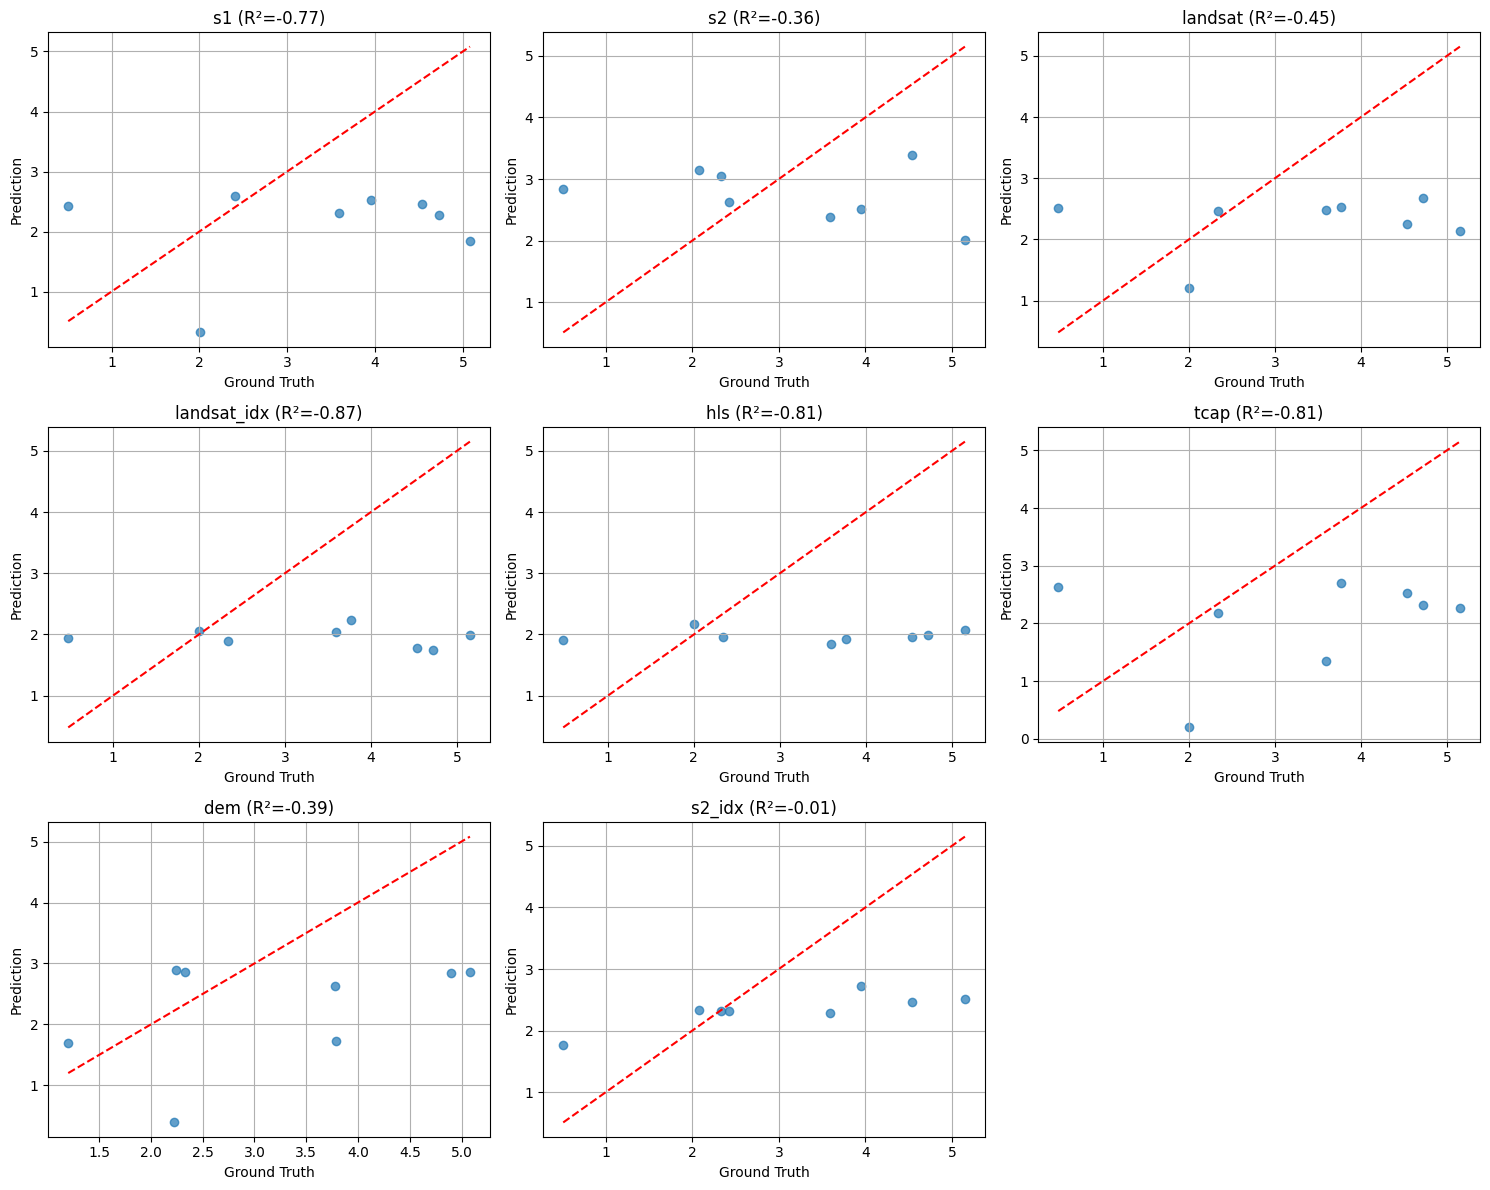

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

eo_products = list(embedding_dict.keys())

n = len(eo_products)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for i, eo_product in enumerate(eo_products):
    # Extract data
    embed = embedding_dict[eo_product]['embeddings']  # (N, D)
    targets = embedding_dict[eo_product]['targets']   # (N,)

    # Split data
    X_train, X_val, y_train, y_val = train_test_split(embed, targets, test_size=0.3, random_state=42)

    # Linear probe
    model = Ridge(alpha=1.0)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    # Metrics
    r2 = r2_score(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))

    print(f"📊 {eo_product} | R²: {r2:.4f} | RMSE: {rmse:.4f}")

    # Plot
    ax = axes[i]
    ax.scatter(y_val, y_pred, alpha=0.7)
    ax.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
    ax.set_xlabel("Ground Truth")
    ax.set_ylabel("Prediction")
    ax.set_title(f"{eo_product} (R²={r2:.2f})")
    ax.grid(True)

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/tmp/ipython-input-25-1796461061.py:60: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_labels))


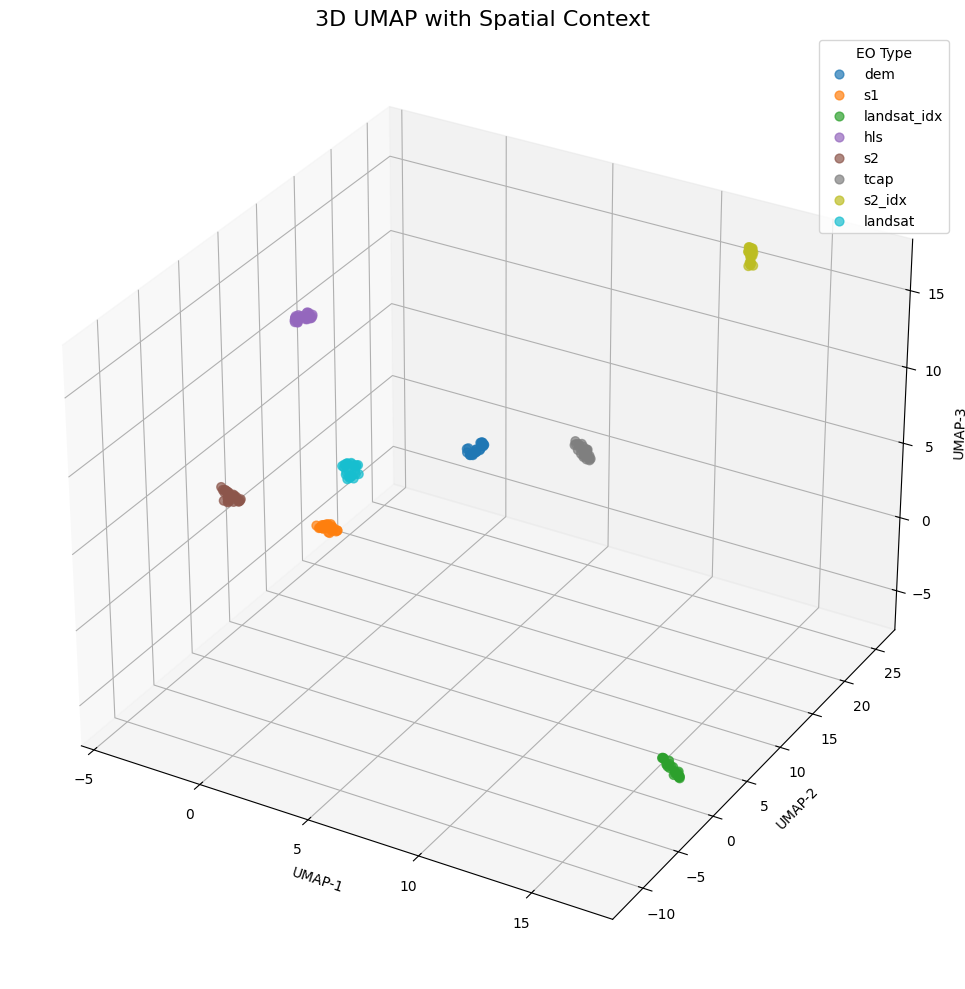

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import umap
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

def visualize_umap_all_embeddings_with_spatial(
    embedding_dict,
    sample_limit=1000,
    n_components=3,
    n_neighbors=25,
    min_dist=0.1,
    alpha=100.0  # spatial weight
):
    all_embeddings = []
    all_coords = []
    all_labels = []

    for eo, data in embedding_dict.items():
        emb = data['embeddings']
        coords = data.get('coords')

        n = len(emb)
        if n == 0 or coords is None:
            continue

        limit = min(sample_limit, n)
        emb = emb[:limit]
        coords = coords[:limit]
        label = [eo] * limit

        all_embeddings.append(emb)
        all_coords.append(coords)
        all_labels.extend(label)

    # Stack data
    X_emb = np.vstack(all_embeddings)
    X_coords = np.vstack(all_coords)

    # Normalize spatial coordinates to [0, 1]
    X_coords = (X_coords - X_coords.min(axis=0)) / (X_coords.max(axis=0) - X_coords.min(axis=0))

    # Scale spatial features
    X_spatial = X_coords * alpha

    # Combine embeddings and spatial info
    X_combined = np.hstack([X_emb, X_spatial])

    # UMAP projection
    reducer = umap.UMAP(
        n_components=n_components,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric='cosine',
        random_state=42
    )
    X_umap = reducer.fit_transform(X_combined)

    # Plot
    unique_labels = list(set(all_labels))
    colors = plt.cm.get_cmap('tab10', len(unique_labels))

    if n_components == 3:
        fig = plt.figure(figsize=(14, 10))
        ax = fig.add_subplot(111, projection='3d')
        for i, eo in enumerate(unique_labels):
            idx = [j for j, label in enumerate(all_labels) if label == eo]
            ax.scatter(X_umap[idx, 0], X_umap[idx, 1], X_umap[idx, 2],
                       label=eo, s=40, alpha=0.7, color=colors(i))
        ax.set_xlabel("UMAP-1")
        ax.set_ylabel("UMAP-2")
        ax.set_zlabel("UMAP-3")
        ax.set_title("3D UMAP with Spatial Context", fontsize=16)
    else:
        plt.figure(figsize=(12, 8))
        for i, eo in enumerate(unique_labels):
            idx = [j for j, label in enumerate(all_labels) if label == eo]
            plt.scatter(X_umap[idx, 0], X_umap[idx, 1],
                        label=eo, s=40, alpha=0.7, color=colors(i))
        plt.xlabel("UMAP-1")
        plt.ylabel("UMAP-2")
        plt.title("2D UMAP with Spatial Context", fontsize=16)

    plt.legend(title="EO Type")
    plt.tight_layout()
    plt.show()

# Example use (with spatial influence)
visualize_umap_all_embeddings_with_spatial(
    embedding_dict,
    n_components=3,
    alpha=5.0  # try 1.0, 5.0, 10.0 to see the effect
)


# Fusion model

Prediction batch stats:
Min: -0.03, Max: -0.03, Mean: -0.03
[Epoch 1] Train Loss: 0.0351 | Val Loss: 1.1424
Prediction batch stats:
Min: 0.01, Max: 0.01, Mean: 0.01
[Epoch 2] Train Loss: 0.0172 | Val Loss: 1.0482
Prediction batch stats:
Min: 0.05, Max: 0.05, Mean: 0.05
[Epoch 3] Train Loss: 0.0066 | Val Loss: 0.9707
Prediction batch stats:
Min: 0.09, Max: 0.09, Mean: 0.09
[Epoch 4] Train Loss: 0.0012 | Val Loss: 0.9008
Prediction batch stats:
Min: 0.12, Max: 0.12, Mean: 0.12
[Epoch 5] Train Loss: 0.0000 | Val Loss: 0.8446
Prediction batch stats:
Min: 0.14, Max: 0.14, Mean: 0.14
[Epoch 6] Train Loss: 0.0014 | Val Loss: 0.8098
Prediction batch stats:
Min: 0.14, Max: 0.14, Mean: 0.14
[Epoch 7] Train Loss: 0.0032 | Val Loss: 0.7988
Prediction batch stats:
Min: 0.14, Max: 0.14, Mean: 0.14
[Epoch 8] Train Loss: 0.0040 | Val Loss: 0.8038
Prediction batch stats:
Min: 0.13, Max: 0.13, Mean: 0.13
[Epoch 9] Train Loss: 0.0037 | Val Loss: 0.8202
Prediction batch stats:
Min: 0.12, Max: 0.12, Mean: 

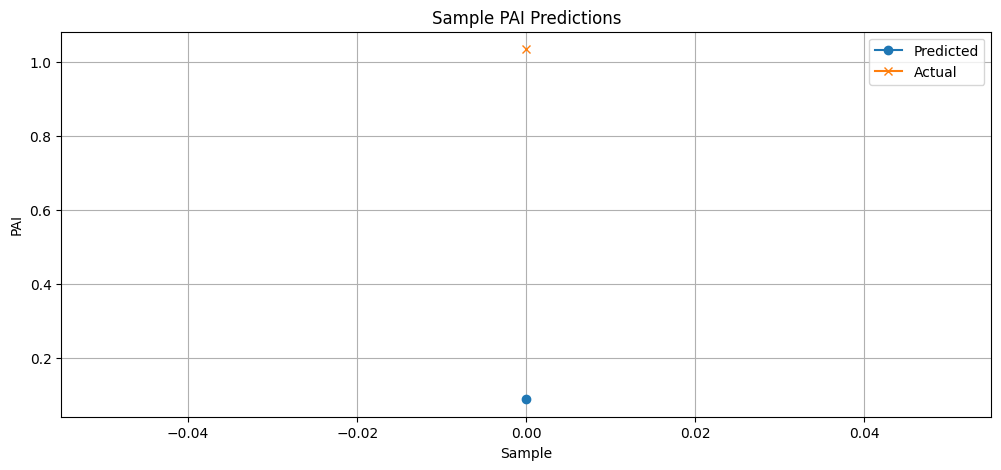

Validation sample count: 1


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import random

# --- Attention-Based Fusion Module ---
class AttentionFusion(nn.Module):
    def __init__(self, num_eos=8, emb_dim=64):
        super().__init__()
        self.query = nn.Linear(emb_dim, emb_dim)
        self.key = nn.Linear(emb_dim, emb_dim)
        self.value = nn.Linear(emb_dim, emb_dim)
        self.scale = emb_dim ** 0.5

    def forward(self, x):  # x: [B, N, D]
        Q = self.query(x)
        K = self.key(x)
        V = self.value(x)
        attn_scores = torch.matmul(Q, K.transpose(-2, -1)) / self.scale  # [B, N, N]
        attn_weights = F.softmax(attn_scores, dim=-1)
        fused = torch.matmul(attn_weights, V)  # [B, N, D]
        return fused.mean(dim=1)  # [B, D]

# --- Regression Model with Fusion ---
class PAIRegressorWithFusion(nn.Module):
    def __init__(self, num_eos=8, emb_dim=64, hidden_dim=128):
        super().__init__()
        self.fusion = AttentionFusion(num_eos, emb_dim)
        self.regressor = nn.Sequential(
            nn.Linear(emb_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):  # x: [B, N, D]
        fused = self.fusion(x)  # [B, D]
        return self.regressor(fused).squeeze(1)

# --- Prepare Fusion Dataset from embedding_dict ---
# def prepare_fusion_dataset(embedding_dict, eo_list):
#     tensors = []
#     for eo in eo_list:
#         emb = torch.tensor(embedding_dict[eo]['embeddings'], dtype=torch.float32)  # [B, D]
#         tensors.append(emb.unsqueeze(1))  # [B, 1, D]
#     x = torch.cat(tensors, dim=1)  # [B, N, D]

#     # Assume targets are the same for all EO sources
#     y = torch.tensor(embedding_dict[eo_list[0]]['targets'], dtype=torch.float32)  # [B]
#     return TensorDataset(x, y)

def align_and_prepare_dataset(embedding_dict, eo_list, emb_dim=64, min_sources=6):
    from collections import defaultdict

    # Step 1: Collect tile -> list of (eo, idx) mappings
    coord_to_eo_idx = defaultdict(list)
    for eo in eo_list:
        coords = embedding_dict[eo]['coords']
        for idx, coord in enumerate(coords):
            coord_tuple = tuple(coord)
            coord_to_eo_idx[coord_tuple].append((eo, idx))

    # Step 2: Filter tiles with at least min_sources available
    filtered_tiles = {coord: entries for coord, entries in coord_to_eo_idx.items() if len(entries) >= min_sources}
    if not filtered_tiles:
        raise ValueError(f"No tiles found with at least {min_sources} sources.")

    # Step 3: Construct aligned dataset
    x_list = []
    y_list = []

    for coord, eo_indices in filtered_tiles.items():
        eo_to_idx = dict(eo_indices)

        emb_stack = []
        for eo in eo_list:
            if eo in eo_to_idx:
                idx = eo_to_idx[eo]
                emb = embedding_dict[eo]['embeddings'][idx]
                # Pad or trim to emb_dim
                if emb.shape[0] < emb_dim:
                    emb = np.pad(emb, (0, emb_dim - emb.shape[0]), mode='constant')
                elif emb.shape[0] > emb_dim:
                    emb = emb[:emb_dim]
            else:
                # Missing EO source — use zero vector
                emb = np.zeros(emb_dim, dtype=np.float32)
            emb_stack.append(torch.tensor(emb, dtype=torch.float32).unsqueeze(0))

        x = torch.cat(emb_stack, dim=0)  # [N, D]
        x_list.append(x.unsqueeze(0))    # [1, N, D]

        # Use target from a reliable EO source (e.g. first in list that exists for this coord)
        for eo in eo_list:
            if eo in eo_to_idx:
                idx = eo_to_idx[eo]
                target = embedding_dict[eo]['targets'][idx]
                y_list.append(torch.tensor(target, dtype=torch.float32))
                break

    x_tensor = torch.cat(x_list, dim=0)  # [B, N, D]
    y_tensor = torch.stack(y_list)       # [B]

    return TensorDataset(x_tensor, y_tensor)



# --- Training Utilities ---
def train_one_epoch(model, dataloader, optimizer, loss_fn, device):
    model.train()
    total_loss = 0
    for x, y in dataloader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        pred = model(x)
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
    return total_loss / len(dataloader.dataset)

def evaluate(model, dataloader, loss_fn, device):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            pred = model(x)
            preds.append(pred.cpu())
            targets.append(y.cpu())
    preds = torch.cat(preds)
    targets = torch.cat(targets)
    loss = loss_fn(preds, targets)

    print("Prediction batch stats:")
    print(f"Min: {preds.min().item():.2f}, Max: {preds.max().item():.2f}, Mean: {preds.mean().item():.2f}")




    return loss.item(), preds, targets

# --- Visualization (Optional) ---
# def plot_sample_predictions(preds, targets, n=20):
#     import matplotlib.pyplot as plt
#     indices = random.sample(range(len(preds)), n)
#     plt.figure(figsize=(12, 5))
#     plt.plot(preds[indices], label="Predicted", marker='o')
#     plt.plot(targets[indices], label="Actual", marker='x')
#     plt.title("Sample PAI Predictions")
#     plt.xlabel("Sample")
#     plt.ylabel("PAI")
#     plt.legend()
#     plt.grid(True)
#     plt.show()

def plot_sample_predictions(preds, targets, n=20):
    import matplotlib.pyplot as plt
    n = min(n, len(preds))  # <-- Prevent sampling too many
    indices = random.sample(range(len(preds)), n)
    plt.figure(figsize=(12, 5))
    plt.plot(range(n), preds[indices], label="Predicted", marker='o')
    plt.plot(range(n), targets[indices], label="Actual", marker='x')
    plt.title("Sample PAI Predictions")
    plt.xlabel("Sample")
    plt.ylabel("PAI")
    plt.legend()
    plt.grid(True)
    plt.show()

# --- Main Pipeline ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
eo_list = ['s1', 's2', 'landsat', 'landsat_idx', 'hls', 'tcap', 'dem', 's2_idx']

# Prepare data
full_dataset = align_and_prepare_dataset(embedding_dict, eo_list)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_ds, val_ds = torch.utils.data.random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32)

# Initialize model
model = PAIRegressorWithFusion(num_eos=len(eo_list), emb_dim=64).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

# Train
epochs = 20
for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, loss_fn, device)
    val_loss, preds, targets = evaluate(model, val_loader, loss_fn, device)
    print(f"[Epoch {epoch}] Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

# Visualize results
plot_sample_predictions(preds.numpy(), targets.numpy())
print(f"Validation sample count: {len(targets)}")

# Inference Prep

In [ ]:
import os
import numpy as np
import rasterio
from rasterio.enums import Resampling
from glob import glob

# Define your GeoTIFF directory
tiff_dir = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/prediction_surface'

# Optional: manually order files if needed for fusion model
tiff_paths = sorted(glob(os.path.join(tiff_dir, '*.tif')))

# Choose base image (usually highest resolution like S1 10m)
base_path = [p for p in tiff_paths if 's1' in os.path.basename(p).lower()][0]

# Read base image for spatial reference
with rasterio.open(base_path) as base_src:
    base_profile = base_src.profile
    base_shape = (base_src.height, base_src.width)
    base_transform = base_src.transform
    base_crs = base_src.crs

# Initialize list for stacked bands
stacked_bands = []

# Resample & align each input image to base
for path in tiff_paths:
    with rasterio.open(path) as src:
        # Read and resample to match base grid
        data = src.read(
            out_shape=(src.count, base_shape[0], base_shape[1]),
            resampling=Resampling.bilinear  # or nearest for categorical data
        )

        # Normalize nodata handling
        data = np.nan_to_num(data, nan=0)

        # If multiband, split along channel dim
        if src.count > 1:
            for b in data:
                stacked_bands.append(b)
        else:
            stacked_bands.append(data[0])

print(f"Stacked {len(stacked_bands)} bands from {len(tiff_paths)} GeoTIFFs")

# Final shape for inference: [C, H, W] or [H, W, C]
input_tensor = np.stack(stacked_bands, axis=0)  # shape: [C, H, W]
# Optional transpose: input_tensor = np.transpose(input_tensor, (1, 2, 0))  # [H, W, C]

# Convert to torch tensor if needed
import torch
input_tensor = torch.from_numpy(input_tensor).float().unsqueeze(0)  # Add batch dim
print("Input tensor shape (B, C, H, W):", input_tensor.shape)


# Debug: inspect raw EO values
print("Per-band stats:")
for i in range(input_tensor.shape[1]):
    band = input_tensor[0, i]  # shape: (H, W)
    print(f"Band {i+1}: min={band.min().item():.2f}, max={band.max().item():.2f}, mean={band.mean().item():.2f}")


Stacked 46 bands from 8 GeoTIFFs
Input tensor shape (B, C, H, W): torch.Size([1, 46, 223, 237])
Per-band stats:
Band 1: min=392.04, max=607.10, mean=576.77
Band 2: min=0.29, max=36.23, mean=7.72
Band 3: min=0.42, max=0.83, mean=0.67
Band 4: min=-0.78, max=-0.50, mean=-0.69
Band 5: min=-0.67, max=-0.49, mean=-0.60
Band 6: min=0.14, max=0.54, mean=0.36
Band 7: min=-0.23, max=0.39, mean=0.16
Band 8: min=-0.39, max=0.23, mean=-0.16
Band 9: min=-0.05, max=0.70, mean=0.52
Band 10: min=0.02, max=0.09, mean=0.05
Band 11: min=0.02, max=0.07, mean=0.04
Band 12: min=7810.24, max=9096.09, mean=8305.48
Band 13: min=0.10, max=0.39, mean=0.21
Band 14: min=0.09, max=0.32, mean=0.19
Band 15: min=8923.21, max=14642.84, mean=11152.06
Band 16: min=0.42, max=0.86, mean=0.61
Band 17: min=-0.78, max=-0.48, mean=-0.65
Band 18: min=-0.70, max=-0.50, mean=-0.63
Band 19: min=0.17, max=0.56, mean=0.31
Band 20: min=-0.21, max=0.37, mean=0.04
Band 21: min=-0.37, max=0.21, mean=-0.04
Band 22: min=-1.00, max=-1.00, m


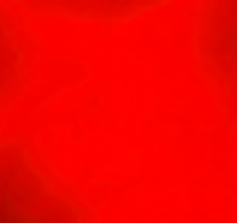

In [ ]:
import folium
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import tempfile
from pyproj import Transformer

# Pick a few bands to visualize (e.g., RGB from Sentinel-2 or any 3 continuous bands)
# Make sure these bands exist and are not all zero
rgb_bands = [0, 1, 2]  # Change indices depending on your data stack

# Get data to plot
visual_array = np.stack([stacked_bands[i] for i in rgb_bands], axis=-1)

# Normalize for display (0-1)
def normalize(arr):
    arr = arr.astype(np.float32)
    min_val = np.nanpercentile(arr, 2)
    max_val = np.nanpercentile(arr, 98)
    return np.clip((arr - min_val) / (max_val - min_val + 1e-5), 0, 1)

rgb_norm = normalize(visual_array)

# Save image temporarily
tmp_img_path = tempfile.mktemp(suffix=".png")
plt.imsave(tmp_img_path, rgb_norm)

# Convert bounds to EPSG:4326
with rasterio.open(base_path) as src:
    bounds = src.bounds
    crs = src.crs

transformer = Transformer.from_crs(crs.to_string(), 'EPSG:4326', always_xy=True)
min_lon, min_lat = transformer.transform(bounds.left, bounds.bottom)
max_lon, max_lat = transformer.transform(bounds.right, bounds.top)

# Create and display the Folium map
center = [(min_lat + max_lat) / 2, (min_lon + max_lon) / 2]
m = folium.Map(location=center, zoom_start=13)

overlay = folium.raster_layers.ImageOverlay(
    name='EO Input Stack (RGB)',
    image=tmp_img_path,
    bounds=[[min_lat, min_lon], [max_lat, max_lon]],
    opacity=0.7,
    interactive=True,
    cross_origin=False,
    zindex=1,
)

overlay.add_to(m)
folium.LayerControl().add_to(m)

# Display the map
m


# Inference

In [ ]:
import torch
import numpy as np

# Your input tensor: shape (1, 46, 223, 237)
input_tensor = input_tensor.squeeze(0)  # (46, 223, 237)

H, W = input_tensor.shape[1], input_tensor.shape[2]
num_pixels = H * W

# Flatten spatial dims: (46, H, W) -> (num_pixels, 46)
flat_pixels = input_tensor.reshape(46, -1).permute(1, 0)  # (num_pixels, 46)

# Define EO bands per source (example, adjust to your data)
eo_band_counts = {
    's1': 6,
    'dem': 4,
    'hls': 6,
    'landsat': 6,
    'landsat_idx': 6,
    'tcap': 6,
    's2': 6,
    's2_idx': 6
}

eo_list = list(eo_band_counts.keys())
emb_dim = 64

# Compute cumulative band indices for slicing
band_indices = []
start = 0
for eo in eo_list:
    end = start + eo_band_counts[eo]
    band_indices.append((start, end))
    start = end

# For each pixel, extract embeddings per EO source and pad/trim to emb_dim
all_embeddings = []
for start_idx, end_idx in band_indices:
    eo_bands = flat_pixels[:, start_idx:end_idx]  # shape: (num_pixels, eo_band_count)
    # Pad or trim to emb_dim
    if eo_bands.shape[1] < emb_dim:
        padding = torch.zeros((num_pixels, emb_dim - eo_bands.shape[1]), dtype=eo_bands.dtype)
        eo_emb = torch.cat([eo_bands, padding], dim=1)
    else:
        eo_emb = eo_bands[:, :emb_dim]
    all_embeddings.append(eo_emb.unsqueeze(1))  # shape: (num_pixels, 1, emb_dim)

# Stack embeddings per EO: shape (num_pixels, 8, emb_dim)
fusion_input = torch.cat(all_embeddings, dim=1)

print(f"Fusion input shape (num_pixels, num_eos, emb_dim): {fusion_input.shape}")
# Expected: (223*237, 8, 64) = (num_pixels, 8, 64)

# Move to device
fusion_input = fusion_input.to(device)

# Run inference in batches to avoid memory issues
batch_size = 4096
model.eval()
predictions = []

with torch.no_grad():
    for i in range(0, num_pixels, batch_size):
        batch = fusion_input[i:i+batch_size]
        preds = model(batch)  # Output shape: (batch_size,)a
        predictions.append(preds.cpu())

# Concatenate all predictions
preds_all = torch.cat(predictions)

# Reshape back to raster shape
pred_map = preds_all.reshape(H, W).numpy()
print(f"Pred map min: {pred_map.min()}, max: {pred_map.max()}, mean: {pred_map.mean()}")

print(f"Prediction map shape: {pred_map.shape}")


Fusion input shape (num_pixels, num_eos, emb_dim): torch.Size([52851, 8, 64])
Pred map min: -101.33883666992188, max: -27.665746688842773, mean: -55.32361602783203
Prediction map shape: (223, 237)


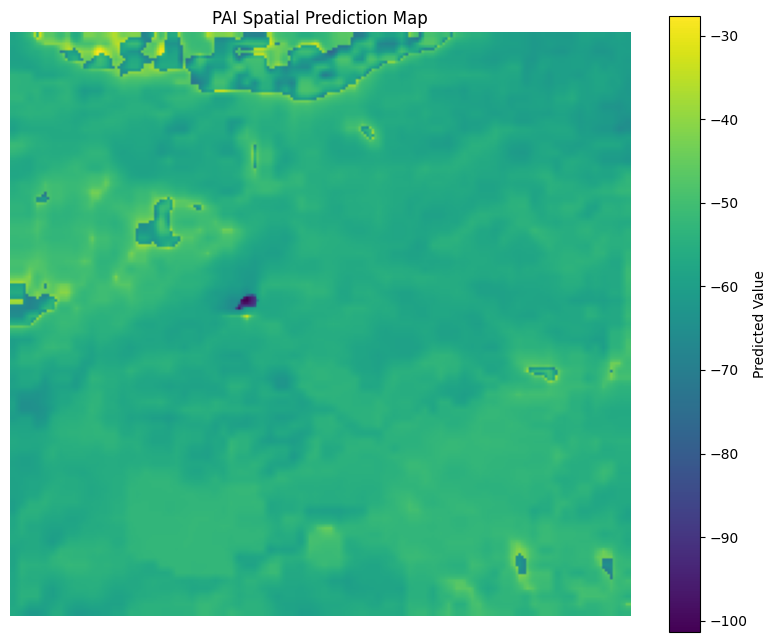

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.imshow(pred_map, cmap='viridis')
plt.colorbar(label="Predicted Value")
plt.title("PAI Spatial Prediction Map")
plt.axis('off')
plt.show()


In [ ]:
import rasterio
from rasterio.transform import from_origin
import os
import numpy as np

# Your predicted map
# pred_map: numpy array of shape (223, 237)

# Save path
output_path = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/results/predicted_pai_map.tif"

# Assume top-left corner (origin) and 10m resolution
# You can tweak (x_min, y_max) to match your actual location
x_min, y_max = 0, 0  # Change if needed
resolution = 10
transform = from_origin(x_min, y_max, resolution, resolution)

# Save GeoTIFF
with rasterio.open(
    output_path,
    'w',
    driver='GTiff',
    height=pred_map.shape[0],
    width=pred_map.shape[1],
    count=1,
    dtype=pred_map.dtype,
    crs='EPSG:4326',  # Set correct CRS if known (e.g., EPSG:32616 for UTM Zone 16N)
    transform=transform
) as dst:
    dst.write(pred_map, 1)

print(f"✅ Saved predicted map to:\n{output_path}")


✅ Saved predicted map to:
/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/results/predicted_pai_map.tif
